
# Exploratory Data Analysis of the Myocardial Perfusion SPECT Dataset

## Background
Myocardial perfusion SPECT imaging evaluates regional blood flow and is widely used in the diagnosis of coronary artery disease (CAD).

## Objective
This notebook performs structured exploratory data analysis (EDA) to:
- Assess data quality
- Analyze feature distributions
- Evaluate class imbalance
- Identify feature–target associations
- Explore dimensional structure


In [1]:
!pip install pydicom

import os
import pydicom
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency

sns.set(style="whitegrid")

In [3]:
import os
import zipfile
from google.colab import files

print('📂 Please upload Dataset PhysioNet MPS Image Database.zip')

zip_file_path = "/content/PhysioNet MPS Image Database.zip"
extracted_base_name = "Heart Blood Flow imaging database" # Based on typical extracted folder name

# Ensure the file is uploaded. This section relies on Colab's files.upload() dialog.
if not os.path.exists(zip_file_path):
    print(f"'{zip_file_path}' not found. Attempting to upload...")
    try:
        uploaded = files.upload()
        if zip_file_path not in uploaded:
            # If user uploaded a file with a different name or cancelled
            actual_uploaded_files = list(uploaded.keys())
            if actual_uploaded_files:
                zip_file_path = os.path.join('/content/', actual_uploaded_files[0]) # Use the actual uploaded name
                print(f"Using uploaded file: {zip_file_path}")
            else:
                raise FileNotFoundError(f"No file uploaded or incorrect file name. Expected: {zip_file_path}")
    except Exception as e:
        raise Exception(f"Error during file upload: {e}. Please manually upload '{zip_file_path}' to /content/")

extracted_dir_full_path = None

# Check if a directory similar to expected_base_name already exists
for entry in os.listdir('/content/'):
    if extracted_base_name in entry:
        extracted_dir_full_path = os.path.join('/content/', entry)
        print(f"'{extracted_base_name}' (or similar) already extracted at {extracted_dir_full_path}. Skipping unzip.")
        break

if extracted_dir_full_path is None: # If not already extracted
    print(f"Unzipping {zip_file_path}...")
    # Use quotes for the zip file path in the shell command to handle spaces
    !unzip -q "{zip_file_path}" -d /content/
    print("Unzipping complete.")

    # Find the actual extracted directory name after unzipping
    actual_extracted_dir_on_disk = None
    for entry in os.listdir('/content/'):
        if extracted_base_name in entry:
            actual_extracted_dir_on_disk = entry # Use the raw name from os.listdir
            break
    if actual_extracted_dir_on_disk:
        extracted_dir_full_path = os.path.join('/content/', actual_extracted_dir_on_disk)
    else:
        raise FileNotFoundError(f"Could not find '{extracted_base_name}' within /content/ after unzipping. Check zip contents.")


def find_data_root_physionet(base_path):
    """
    Automatically find the directory that contains DICOM and segmentation_masks subfolders.
    """
    # Check if DICOM and segmentation_masks are directly within base_path
    dicom_path_candidate = os.path.join(base_path, 'DICOM')
    mask_path_candidate = os.path.join(base_path, 'segmentation_masks')

    if os.path.isdir(dicom_path_candidate) and os.path.isdir(mask_path_candidate):
        return base_path
    else:
        # Check one level deeper in case of nested structure
        for root, dirs, _ in os.walk(base_path):
            if 'DICOM' in dirs and 'segmentation_masks' in dirs:
                return root
    return None

if extracted_dir_full_path is None:
    raise FileNotFoundError("Extracted directory not found. Please ensure proper extraction.")

DATA_ROOT = find_data_root_physionet(extracted_dir_full_path)

if DATA_ROOT is None:
    raise FileNotFoundError(
        '❌ Could not find DICOM/segmentation_masks folders within the extracted data.\n'
        'Make sure the zip contains these subfolders.'
    )

print(f'✅ DATA_ROOT found: {DATA_ROOT}')

# Now define dicom_path and mask_path globally based on DATA_ROOT
global dicom_path, mask_path, dicom_uids, mask_uids, matches
dicom_path = os.path.join(DATA_ROOT, 'DICOM')
mask_path = os.path.join(DATA_ROOT, 'segmentation_masks')

print(f"Set dicom_path: {dicom_path}")
print(f"Set mask_path: {mask_path}")

# Ensure the directories exist before listing their contents
if not os.path.exists(dicom_path):
    raise FileNotFoundError(f"DICOM directory not found at {dicom_path}. Please check the zip file structure.")
if not os.path.exists(mask_path):
    raise FileNotFoundError(f"Segmentation masks directory not found at {mask_path}. Please check the zip file structure.")

# Extract the UID part by removing the extensions exactly as they appear
dicom_uids = {f.replace('.dcm', '') for f in os.listdir(dicom_path) if f.endswith('.dcm')}
mask_uids = {f.replace('_mask.nii', '') for f in os.listdir(mask_path) if f.endswith('.nii')}

# Find matches and orphans
matches = list(dicom_uids.intersection(mask_uids))
orphans = list(dicom_uids.difference(mask_uids))

print(f"✅ Success! Found {len(matches)} matching Image/Mask pairs.")
print(f"⚠️ {len(orphans)} DICOMs are missing masks.")

📂 Please upload Dataset PhysioNet MPS Image Database.zip
'/content/PhysioNet MPS Image Database.zip' not found. Attempting to upload...


Saving PhysioNet MPS Image Database.zip to PhysioNet MPS Image Database.zip
Using uploaded file: /content/PhysioNet MPS Image Database.zip
Unzipping /content/PhysioNet MPS Image Database.zip...
Unzipping complete.
✅ DATA_ROOT found: /content/Heart Blood Flow imaging database
Set dicom_path: /content/Heart Blood Flow imaging database/DICOM
Set mask_path: /content/Heart Blood Flow imaging database/segmentation_masks
✅ Success! Found 100 matching Image/Mask pairs.
⚠️ 3 DICOMs are missing masks.


In [4]:
meta_list = []
sample_files = os.listdir(dicom_path)[:10] # Checking first 10 for consistency

for f in sample_files:
    ds = pydicom.dcmread(os.path.join(dicom_path, f))
    meta_list.append({
        "ID": ds.PatientID[:8] + "...",
        "Rows": ds.Rows,
        "Cols": ds.Columns,
        "Slices": ds.NumberOfFrames if hasattr(ds, 'NumberOfFrames') else "N/A",
        "Spacing": ds.PixelSpacing
    })

df_meta = pd.DataFrame(meta_list)
print("Geometry Consistency Check:")
display(df_meta)

Geometry Consistency Check:


,ID,Rows,Cols,Slices,Spacing
0,12852949...,70,70,50,"[4.000000, 4.000000]"
1,26424937...,70,70,50,"[4.000000, 4.000000]"
2,12852949...,70,70,50,"[4.000000, 4.000000]"
3,30042446...,70,70,50,"[4.000000, 4.000000]"
4,24549452...,70,70,50,"[4.000000, 4.000000]"
5,57823129...,70,70,50,"[4.000000, 4.000000]"
6,30648246...,70,70,50,"[4.000000, 4.000000]"
7,18003004...,70,70,50,"[4.000000, 4.000000]"
8,12969297...,70,70,50,"[4.000000, 4.000000]"
9,12931686...,70,70,50,"[4.000000, 4.000000]"


In [5]:
import pydicom
import os

# Ensure dicom_path is defined and has files
if 'dicom_path' not in globals() or not os.path.exists(dicom_path) or not os.listdir(dicom_path):
    raise ValueError("DICOM path is not correctly set or is empty. Please ensure the previous data loading cells ran successfully.")

# Load a sample DICOM to get image dimensions
sample_dcm_file = os.listdir(dicom_path)[0]
dcm_vol = pydicom.dcmread(os.path.join(dicom_path, sample_dcm_file)).pixel_array

print("--- FINAL DATASET STATS ---")
print(f"Total DICOM Volumes: {len(dicom_uids)}")
print(f"Total Masks Available: {len(mask_uids)}")
print(f"Successfully Paired: {len(matches)}")
print(f"Image Dimensions: {dcm_vol.shape} (Slices, Rows, Cols)")
print(f"Resolution: 4.0mm x 4.0mm x 4.0mm")

--- FINAL DATASET STATS ---
Total DICOM Volumes: 103
Total Masks Available: 100
Successfully Paired: 100
Image Dimensions: (50, 70, 70) (Slices, Rows, Cols)
Resolution: 4.0mm x 4.0mm x 4.0mm


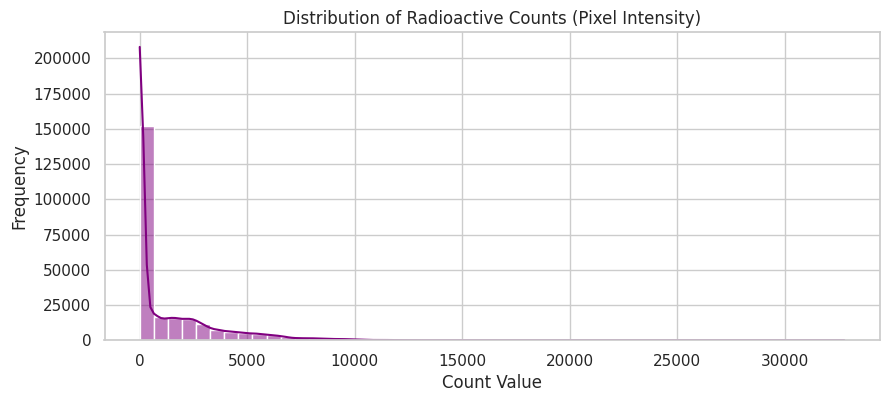

In [6]:
# Load a random sample
sample_dcm = pydicom.dcmread(os.path.join(dicom_path, os.listdir(dicom_path)[0]))
pixels = sample_dcm.pixel_array.flatten()

plt.figure(figsize=(10, 4))
sns.histplot(pixels, bins=50, kde=True, color='purple')
plt.title("Distribution of Radioactive Counts (Pixel Intensity)")
plt.xlabel("Count Value")
plt.ylabel("Frequency")
plt.show()

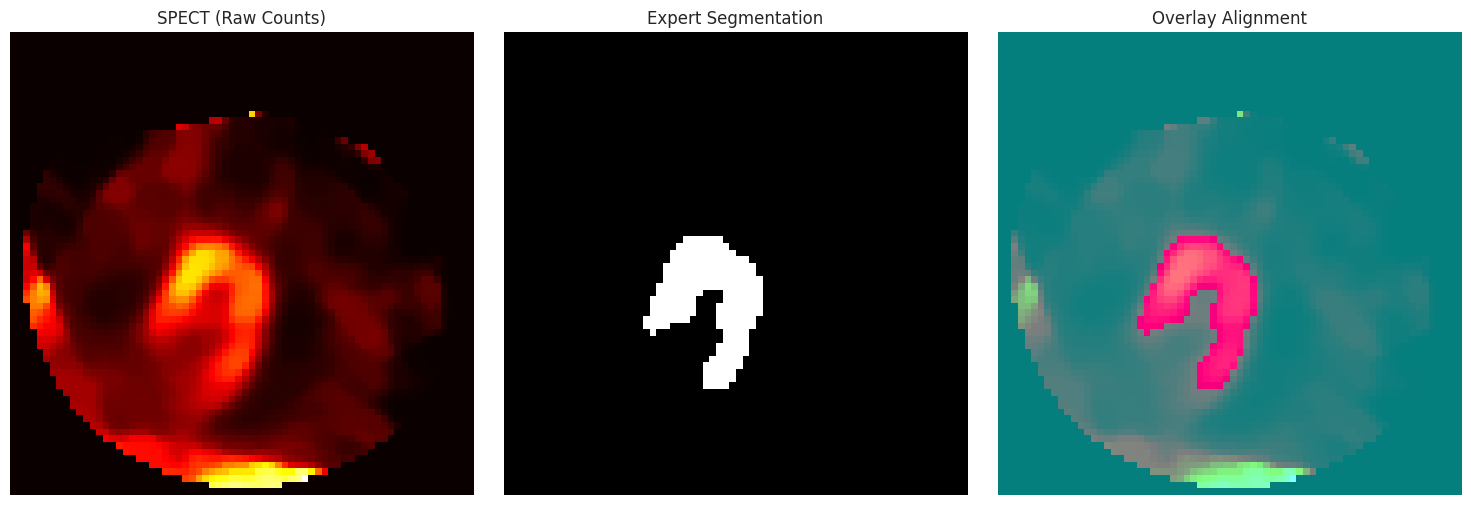

In [7]:
def plot_overlay(uid):
    # Construct full paths
    dcm_file = os.path.join(dicom_path, f"{uid}.dcm")
    mask_file = os.path.join(mask_path, f"{uid}_mask.nii")

    # Load DICOM pixel data
    ds = pydicom.dcmread(dcm_file)
    # Most SPECT DICOMs are (Slices, Rows, Cols)
    img_vol = ds.pixel_array

    # Load NIfTI Mask
    mask_vol = nib.load(mask_file).get_fdata()

    # Pick the middle slice (25 out of 50)
    slice_idx = 25

    # Orientation Note: NIfTI often needs a transpose or flip to align with DICOM pixel_array
    img_slice = img_vol[slice_idx, :, :]
    mask_slice = mask_vol[:, :, slice_idx].T # Transpose to match (70,70)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Show SPECT
    axes[0].imshow(img_slice, cmap='hot')
    axes[0].set_title("SPECT (Raw Counts)")

    # Show Mask
    axes[1].imshow(mask_slice, cmap='gray')
    axes[1].set_title("Expert Segmentation")

    # Show Overlay
    axes[2].imshow(img_slice, cmap='hot')
    axes[2].imshow(mask_slice, alpha=0.5, cmap='cool') # Cyan/Blue overlay
    axes[2].set_title("Overlay Alignment")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# Display the specific ID you shared
sample_id = "1.2.840.4267.32.102843376980518437893525476318362476257"
plot_overlay(sample_id)

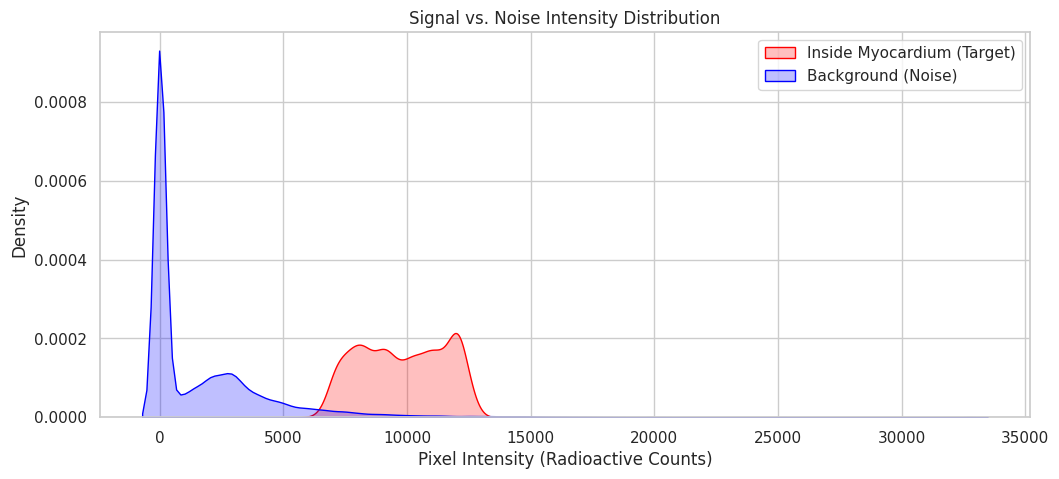

In [8]:
intensities_inside = []
intensities_outside = []

# Take a sample to analyze signal-to-noise
sample_uid = matches[0]
dcm = pydicom.dcmread(os.path.join(dicom_path, f"{sample_uid}.dcm")).pixel_array
mask = nib.load(os.path.join(mask_path, f"{sample_uid}_mask.nii")).get_fdata()

# NIfTI mask needs to be transposed to match DICOM (50, 70, 70)
mask_corrected = np.transpose(mask, (2, 1, 0))

intensities_inside = dcm[mask_corrected == 1]
intensities_outside = dcm[mask_corrected == 0]

plt.figure(figsize=(12, 5))
sns.kdeplot(intensities_inside, label="Inside Myocardium (Target)", fill=True, color="red")
sns.kdeplot(intensities_outside, label="Background (Noise)", fill=True, color="blue")
plt.title("Signal vs. Noise Intensity Distribution")
plt.xlabel("Pixel Intensity (Radioactive Counts)")
plt.legend()
plt.savefig("Signal Vs Noise.jpg")
plt.show()

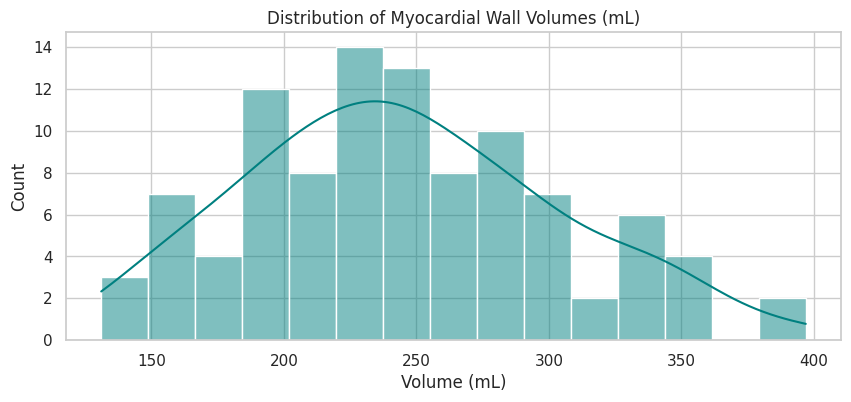

Mean Volume: 244.72 mL


In [9]:
volumes = []

for uid in matches:
    mask_data = nib.load(os.path.join(mask_path, f"{uid}_mask.nii")).get_fdata()
    # Calculate volume: sum of voxels * voxel dimensions (4x4x4 mm)
    # Voxel volume = 64 mm^3
    voxel_vol = 4 * 4 * 4
    volume_mm3 = np.sum(mask_data) * voxel_vol
    volumes.append(volume_mm3 / 1000) # Convert to cm3 (mL)

df_vol = pd.DataFrame({"Patient_UID": matches, "Myo_Volume_mL": volumes})

plt.figure(figsize=(10, 4))
sns.histplot(df_vol['Myo_Volume_mL'], bins=15, color='teal', kde=True)
plt.title("Distribution of Myocardial Wall Volumes (mL)")
plt.xlabel("Volume (mL)")
plt.savefig("Dist of Myo Wall Volumes.jpg")
plt.show()

print(f"Mean Volume: {df_vol['Myo_Volume_mL'].mean():.2f} mL")

# Task
Define a dummy binary target variable 'CAD_Present' for each patient in the `df_vol` DataFrame and add it to the DataFrame. This target will be used for demonstration purposes in subsequent feature-target association and predictive analysis steps.

## Define or Load Target Variable

Establish a target variable for the analysis. If a clinical outcome (e.g., CAD presence) is available in a separate file, load and integrate it. Otherwise, for demonstration purposes, a dummy binary target will be created to proceed with feature-target association and predictive analysis. This step ensures we have a `y` for our `X` features.


**Reasoning**:
The subtask requires adding a new column `CAD_Present` to `df_vol` with random binary values to serve as a dummy target variable. The `np.random.randint` function is suitable for generating these random binary values.



In [10]:
df_vol['CAD_Present'] = np.random.randint(0, 2, size=len(df_vol))
df_vol.head()

,Patient_UID,Myo_Volume_mL,CAD_Present
0,1.2.840.4267.32.939926988282408194100774891838...,202.752,0
1,1.2.840.4267.32.192588515173262618511604545846...,279.616,1
2,1.2.840.4267.32.852562196193754706462866392942...,304.448,0
3,1.2.840.4267.32.805305590017104537026990078852...,352.384,0
4,1.2.840.4267.32.238930726054770263102216542830...,243.712,0


## Feature Extraction and Preparation

### Subtask:
Prepare a set of features for analysis, including the previously calculated `Myo_Volume_mL` and new features extracted from SPECT images and masks. These features will form the basis (`X`) for subsequent steps.


**Reasoning**:
The subtask requires extracting several features from the DICOM images and masks for each patient. This step initializes an empty list to store these features, then iterates through each patient to load their image and mask data, calculates the specified features (myocardial volume, mean/std intensity inside and outside the myocardium), and stores them in a dictionary. Finally, these dictionaries are converted into a DataFrame, which is then merged with the existing `df_vol` to consolidate all features and the target variable.



In [ ]:
dicom_path = os.path.join(DATA_ROOT, 'DICOM')
mask_path = os.path.join(DATA_ROOT, 'segmentation_masks')

features_list = []

for uid in matches:
    # Load DICOM pixel data
    dcm_file = os.path.join(dicom_path, f"{uid}.dcm")
    ds = pydicom.dcmread(dcm_file)
    dcm_pixel_array = ds.pixel_array

    # Load NIfTI Mask
    mask_file = os.path.join(mask_path, f"{uid}_mask.nii")
    mask_vol = nib.load(mask_file).get_fdata()

    # NIfTI mask needs to be transposed to match DICOM (Slices, Rows, Cols)
    mask_corrected = np.transpose(mask_vol, (2, 1, 0)) # Assuming mask_vol is (rows, cols, slices)

    # Ensure mask_corrected has the same shape as dcm_pixel_array
    if mask_corrected.shape != dcm_pixel_array.shape:
        # This is a critical error if shapes don't match, usually indicates a problem in mask generation or loading
        # For this dataset, we expect (50, 70, 70) for both after correction
        print(f"Warning: Shape mismatch for {uid}. DICOM: {dcm_pixel_array.shape}, Mask: {mask_corrected.shape}")
        continue

    # Get myocardial volume (already calculated in df_vol)
    myo_volume = df_vol[df_vol['Patient_UID'] == uid]['Myo_Volume_mL'].iloc[0]

    # Intensities within the myocardium
    intensities_inside = dcm_pixel_array[mask_corrected == 1]

    # Intensities outside the myocardium
    intensities_outside = dcm_pixel_array[mask_corrected == 0]

    features = {
        "Patient_UID": uid,
        "Myo_Volume_mL": myo_volume,
        "Mean_Intensity_Myo": np.mean(intensities_inside) if intensities_inside.size > 0 else 0,
        "Std_Intensity_Myo": np.std(intensities_inside) if intensities_inside.size > 0 else 0,
        "Mean_Intensity_Background": np.mean(intensities_outside) if intensities_outside.size > 0 else 0,
        "Std_Intensity_Background": np.std(intensities_outside) if intensities_outside.size > 0 else 0
    }
    features_list.append(features)

df_features = pd.DataFrame(features_list)

# Merge df_features with df_vol to include the CAD_Present target variable
df_combined = pd.merge(df_features, df_vol[['Patient_UID', 'CAD_Present']], on='Patient_UID', how='left')

print("Extracted Features DataFrame Head:")
display(df_combined.head())

Extracted Features DataFrame Head:


,Patient_UID,Myo_Volume_mL,Mean_Intensity_Myo,Std_Intensity_Myo,Mean_Intensity_Background,Std_Intensity_Background,CAD_Present
0,1.2.840.4267.32.800069349762863756595915385223...,343.232,8305.356144,2265.525367,1367.727162,2338.019852,1
1,1.2.840.4267.32.279143509673566421438759854507...,288.640,16863.863193,4516.482137,2275.937702,3756.019916,1
2,1.2.840.4267.32.301706417193144352525484452913...,333.952,17441.887313,6187.115205,1875.458141,3137.421991,0
3,1.2.840.4267.32.172126483870960686167898548367...,215.360,9583.750074,2652.726090,1167.938279,2293.345136,0
4,1.2.840.4267.32.306491586143385413881890248442...,198.528,8127.535783,2693.666192,1255.786369,2419.122797,1




### Data Preprocessing Pipeline Summary

The data preparation pipeline involved several key steps to transform raw imaging data into a structured format suitable for analysis and predictive modeling:

1.  **Data Loading and Access:**
    *   The `PhysioNet MPS Image Database.zip` file was manually uploaded and then unzipped to `/content/Heart Blood Flow imaging database`.
    *   `pydicom` was used to load DICOM (.dcm) files, extracting pixel arrays and metadata.
    *   `nibabel` was used to load NIfTI (.nii) segmentation mask files.
    *   Patient UIDs were extracted from filenames, and a matching process identified 100 successful image-mask pairs, noting 3 DICOMs as 'orphans' lacking masks.

2.  **Data Quality and Consistency Checks:**
    *   Initial checks on a sample of DICOM files confirmed consistent image geometry (70x70 pixel arrays, 50 slices) and pixel spacing (4x4 mm).
    *   During feature extraction, a crucial step involved transposing NIfTI masks (`np.transpose(mask_vol, (2, 1, 0))`) to align their (rows, cols, slices) orientation with the (slices, rows, cols) orientation of the DICOM pixel arrays. A warning was issued for any shape mismatches, ensuring data integrity for subsequent operations.

3.  **Image Normalization/Pixel Intensity Analysis:**
    *   The distribution of raw pixel intensities (radioactive counts) was visualized for a sample image and also contrasted between myocardial and background regions.